<a href="https://colab.research.google.com/github/Diego-Eduardo-Marquez-Herrera/probabilidad-y-estadistica/blob/main/probabilidad-y-estadistica/practica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **probabilidad y Estadistica**

## **unidad 1**

###**practica 3. tabla de frecuencias y reglas de sturges...*

###Docente: *Dr. José Gabriel Rodriguez Rivas*

###Alumno: Diego Eduardo Marquez Herrera

In [1]:
import random
import math
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
edades = []
for i in range(100):
    numero_aleatorio = random.randint(18, 70)
    edades.append(numero_aleatorio)

print("Edades generadas:", edades)


Edades generadas: [43, 49, 51, 46, 19, 44, 33, 40, 29, 23, 19, 32, 38, 53, 52, 66, 66, 33, 70, 67, 23, 18, 63, 28, 49, 21, 51, 35, 42, 52, 28, 58, 27, 42, 21, 55, 24, 25, 39, 53, 59, 58, 49, 31, 24, 34, 24, 23, 46, 55, 36, 66, 39, 38, 57, 24, 50, 43, 49, 40, 23, 32, 25, 40, 41, 53, 57, 39, 27, 62, 47, 47, 20, 58, 69, 47, 28, 59, 50, 22, 55, 34, 66, 34, 39, 49, 30, 64, 31, 62, 47, 36, 31, 27, 68, 20, 50, 63, 53, 35]


In [3]:
df = pd.DataFrame(edades, columns=['Edad'])

In [4]:
tabla_frecuencias = df['Edad'].value_counts().reset_index()
tabla_frecuencias.columns = ['Edad', 'Frecuencia']
tabla_frecuencias = tabla_frecuencias.sort_values(by='Edad')

In [5]:
n = len(edades)
K = int(1 + math.log2(n))

print(f"\nValor de n = {n}")
print(f"Número de intervalos (K) = {K}")


Valor de n = 100
Número de intervalos (K) = 7


In [6]:
tabla_frecuencia = pd.cut(df['Edad'], bins=K, include_lowest=True).value_counts().reset_index()
tabla_frecuencia.columns = ['Clase', 'Frec']
tabla_frecuencia = tabla_frecuencia.sort_values(by='Clase')

In [7]:
tabla_frecuencia['Frec Rel'] = tabla_frecuencia['Frec'] / n
tabla_frecuencia['Frec Porc'] = (tabla_frecuencia['Frec'] / n) * 100
tabla_frecuencia['Frec Ac'] = tabla_frecuencia['Frec'].cumsum()
tabla_frecuencia['Frec Rel Ac'] = tabla_frecuencia['Frec Rel'].cumsum()
tabla_frecuencia['Frec Porc Ac'] = tabla_frecuencia['Frec Porc'].cumsum()

print("\nTabla de Frecuencias según Regla de Sturges:")
print(tabla_frecuencia)


Tabla de Frecuencias según Regla de Sturges:
              Clase  Frec  Frec Rel  Frec Porc  Frec Ac  Frec Rel Ac  \
2  (17.947, 25.429]    18      0.18       18.0       18         0.18   
3  (25.429, 32.857]    13      0.13       13.0       31         0.31   
1  (32.857, 40.286]    18      0.18       18.0       49         0.49   
4  (40.286, 47.714]    12      0.12       12.0       61         0.61   
0  (47.714, 55.143]    19      0.19       19.0       80         0.80   
6  (55.143, 62.571]     9      0.09        9.0       89         0.89   
5    (62.571, 70.0]    11      0.11       11.0      100         1.00   

   Frec Porc Ac  
2          18.0  
3          31.0  
1          49.0  
4          61.0  
0          80.0  
6          89.0  
5         100.0  


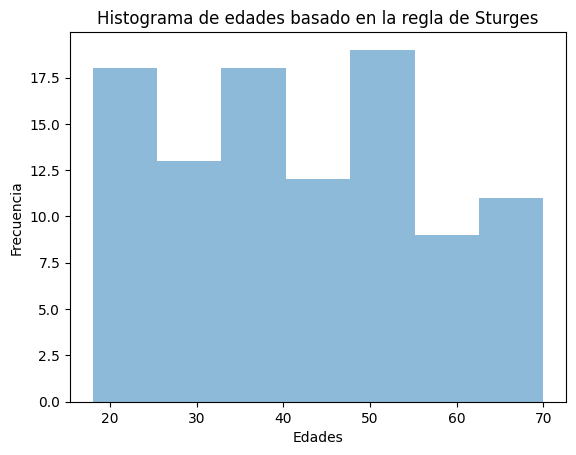

In [8]:
plt.figure()
plt.hist(df['Edad'], bins=K, alpha=0.5)
plt.title("Histograma de edades basado en la regla de Sturges")
plt.xlabel("Edades")
plt.ylabel("Frecuencia")
plt.show()